In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
sgph = pd.read_csv(r'E:\aabc\myDeepTree\data-250415/ba_qc\sgph/sgphfeature_contribution_ratio.csv')# activation rate
enah = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/enah/enahfeature_contribution_ratio.csv')# activation rate
guch = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/guch/guchfeature_contribution_ratio.csv')# activation rate
asih = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/asih/asihfeature_contribution_ratio.csv')# activation rate
mosh = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/mosh/moshfeature_contribution_ratio.csv')# activation rate

sgp = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/sgp/sgpfeature_contribution_ratio.csv')
ena = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/ena/enafeature_contribution_ratio.csv')
asi = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/asi/asifeature_contribution_ratio.csv')
guc = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/guc/gucfeature_contribution_ratio.csv')
mos = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/mos/mosfeature_contribution_ratio.csv')

guc

,Unnamed: 0,0
0,BBS_B,18.170615
1,BBS_G,10.733571
2,BSF_G,10.447783
3,BA_R,8.482264
4,BA_B,7.349590
5,AE_BR,6.605294
6,BSF_B,6.096936
7,BS_B,6.076529
8,AE_BG,5.670513
9,SSA_B,3.986258


In [3]:
# Extract variable names and corresponding values from the DataFrame
variable_names_guc = guc.iloc[:, 0].values
variable_values_guc = guc.iloc[:, 1].values

variable_dict_guc = dict(zip(variable_names_guc, variable_values_guc))

variable_names_sgp = sgp.iloc[:, 0].values
variable_values_sgp = sgp.iloc[:, 1].values

variable_dict_sgp = dict(zip(variable_names_sgp, variable_values_sgp))

variable_names_ena = ena.iloc[:, 0].values
variable_values_ena = ena.iloc[:, 1].values

variable_dict_ena = dict(zip(variable_names_ena, variable_values_ena))

variable_names_asi = asi.iloc[:, 0].values
variable_values_asi = asi.iloc[:, 1].values

variable_dict_asi = dict(zip(variable_names_asi, variable_values_asi))

variable_names_mos = mos.iloc[:, 0].values
variable_values_mos = mos.iloc[:, 1].values

variable_dict_mos = dict(zip(variable_names_mos, variable_values_mos))

variable_names_guch = guch.iloc[:, 0].values
variable_values_guch = guch.iloc[:, 1].values

variable_dict_guch = dict(zip(variable_names_guch, variable_values_guch))

variable_names_sgph = sgph.iloc[:, 0].values
variable_values_sgph = sgph.iloc[:, 1].values

variable_dict_sgph = dict(zip(variable_names_sgph, variable_values_sgph))

variable_names_enah = enah.iloc[:, 0].values
variable_values_enah = enah.iloc[:, 1].values

variable_dict_enah = dict(zip(variable_names_enah, variable_values_enah))

variable_names_asih = asih.iloc[:, 0].values
variable_values_asih = asih.iloc[:, 1].values

variable_dict_asih = dict(zip(variable_names_asih, variable_values_asih))

variable_names_mosh = mosh.iloc[:, 0].values
variable_values_mosh = mosh.iloc[:, 1].values

variable_dict_mosh = dict(zip(variable_names_mosh, variable_values_mosh))
variable_dict_asi

{'BS_B': 22.242863342407336,
 'BBS_B': 12.66212210635444,
 'AE_BR': 12.50348244782917,
 'AE_BG': 11.758446001183426,
 'BA_B': 7.164318227820416,
 'BBS_G': 6.8694183153742925,
 'BA_R': 4.273389587409574,
 'SSA_R': 4.2487628481351685,
 'AE_GR': 4.020655566493243,
 'SSA_B': 3.508655218029353,
 'SSA_G': 2.9177595296875367,
 'BS_G': 2.3674057858509765,
 'BBS_R': 1.2798827173399574,
 'BSF_R': 1.1251187551397488,
 'BA_G': 1.0671741365950334,
 'BSF_G': 0.9972795854776384,
 'BS_R': 0.678182311364582,
 'BSF_B': 0.315083517508106}

In [4]:
AE_ASI=variable_dict_asi['AE_BG']+variable_dict_asi['AE_BR']+variable_dict_asi['AE_GR']
BS_ASI=variable_dict_asi['BS_B']+variable_dict_asi['BS_G']+variable_dict_asi['BS_R']
BA_ASI=variable_dict_asi['BA_B']+variable_dict_asi['BA_G']+variable_dict_asi['BA_R']
BBS_ASI=variable_dict_asi['BBS_B']+variable_dict_asi['BBS_G']+variable_dict_asi['BBS_R']
SSA_ASI=variable_dict_asi['SSA_B']+variable_dict_asi['SSA_G']+variable_dict_asi['SSA_R']
# G_ASI=variable_dict_asi['g_B']+variable_dict_asi['g_G']+variable_dict_asi['g_R']
BSF_ASI=variable_dict_asi['BSF_B']+variable_dict_asi['BSF_G']+variable_dict_asi['BSF_R']
# TRAN_ASI=variable_dict_asi['TR_B']+variable_dict_asi['TR_G']+variable_dict_asi['TR_R']
# T_ASI=variable_dict_asi['T_Neph_Dry']
# RH_ASI=variable_dict_asi['RH']
# P_ASI=variable_dict_asi['P_Neph_Dry']

AE_ENA=variable_dict_ena['AE_BG']+variable_dict_ena['AE_BR']+variable_dict_ena['AE_GR']
BS_ENA=variable_dict_ena['BS_B']+variable_dict_ena['BS_G']+variable_dict_ena['BA_R']
BA_ENA=variable_dict_ena['BA_B']+variable_dict_ena['BA_G']+variable_dict_ena['BA_R']
BBS_ENA=variable_dict_ena['BBS_B']+variable_dict_ena['BBS_G']+variable_dict_ena['BBS_R']
SSA_ENA=variable_dict_ena['SSA_B']+variable_dict_ena['SSA_G']+variable_dict_ena['SSA_R']
# G_ENA=variable_dict_ena['g_B']+variable_dict_ena['g_G']+variable_dict_ena['g_R']
BSF_ENA=variable_dict_ena['BSF_B']+variable_dict_ena['BSF_G']+variable_dict_ena['BSF_R']
# TRAN_ENA=variable_dict_ena['TR_B']+variable_dict_ena['TR_G']+variable_dict_ena['TR_R']
# T_ENA=variable_dict_ena['T_Neph_Dry']
# RH_ENA=variable_dict_ena['RH']
# P_ENA=variable_dict_ena['P_Neph_Dry']

AE_SGP=variable_dict_sgp['AE_BG']+variable_dict_sgp['AE_BR']+variable_dict_sgp['AE_GR']
BS_SGP=variable_dict_sgp['BS_B']+variable_dict_sgp['BS_G']+variable_dict_sgp['BS_R']
BA_SGP=variable_dict_sgp['BA_B']+variable_dict_sgp['BA_G']+variable_dict_sgp['BA_R']
BBS_SGP=variable_dict_sgp['BBS_B']+variable_dict_sgp['BBS_G']+variable_dict_sgp['BBS_R']
SSA_SGP=variable_dict_sgp['SSA_B']+variable_dict_sgp['SSA_G']+variable_dict_sgp['SSA_R']
# G_SGP=variable_dict_sgp['g_B']+variable_dict_sgp['g_G']+variable_dict_sgp['g_R']
BSF_SGP=variable_dict_sgp['BSF_B']+variable_dict_sgp['BSF_G']+variable_dict_sgp['BSF_R']
# TRAN_SGP=variable_dict_sgp['TR_B']+variable_dict_sgp['TR_G']+variable_dict_sgp['TR_R']
# T_SGP=variable_dict_sgp['T_Neph_Dry']
# RH_SGP=variable_dict_sgp['RH']
# P_SGP=variable_dict_sgp['P_Neph_Dry']

AE_GUC=variable_dict_guc['AE_BG']+variable_dict_guc['AE_BR']+variable_dict_guc['AE_GR']
BS_GUC=variable_dict_guc['BS_B']+variable_dict_guc['BS_G']+variable_dict_guc['BS_R']
BA_GUC=variable_dict_guc['BA_B']+variable_dict_guc['BA_G']+variable_dict_guc['BA_R']
BBS_GUC=variable_dict_guc['BBS_B']+variable_dict_guc['BBS_G']+variable_dict_guc['BBS_R']
SSA_GUC=variable_dict_guc['SSA_B']+variable_dict_guc['SSA_G']+variable_dict_guc['SSA_R']
# G_GUC=variable_dict_guc['g_B']+variable_dict_guc['g_G']+variable_dict_guc['g_R']
BSF_GUC=variable_dict_guc['BSF_B']+variable_dict_guc['BSF_G']+variable_dict_guc['BSF_R']
# TRAN_GUC=variable_dict_guc['TR_B']+variable_dict_guc['TR_G']+variable_dict_guc['TR_R']
# T_GUC=variable_dict_guc['T_Neph_Dry']
# RH_GUC=variable_dict_guc['RH']
# P_GUC=variable_dict_guc['P_Neph_Dry']



In [5]:
AE_mos=variable_dict_mos['AE_BG']+variable_dict_mos['AE_BR']+variable_dict_mos['AE_GR']
BS_mos=variable_dict_mos['BS_B']+variable_dict_mos['BS_G']+variable_dict_mos['BS_R']
BA_mos=variable_dict_mos['BA_B']+variable_dict_mos['BA_G']+variable_dict_mos['BA_R']
BBS_mos=variable_dict_mos['BBS_B']+variable_dict_mos['BBS_G']+variable_dict_mos['BBS_R']
SSA_mos=variable_dict_mos['SSA_B']+variable_dict_mos['SSA_G']+variable_dict_mos['SSA_R']
# G_mos=variable_dict_mos['g_B']+variable_dict_mos['g_G']+variable_dict_mos['g_R']
BSF_mos=variable_dict_mos['BSF_B']+variable_dict_mos['BSF_G']+variable_dict_mos['BSF_R']
# TRAN_mos=variable_dict_mos['TR_B']+variable_dict_mos['TR_G']+variable_dict_mos['TR_R']
# T_mos=variable_dict_mos['T_Neph_Dry']
# RH_mos=variable_dict_mos['RH']
# P_mos=variable_dict_mos['P_Neph_Dry']

In [6]:
AE_ASIh=variable_dict_asih['AE_BG']+variable_dict_asih['AE_BR']+variable_dict_asih['AE_GR']
BS_ASIh=variable_dict_asih['BS_B']+variable_dict_asih['BS_G']+variable_dict_asih['BS_R']
BA_ASIh=variable_dict_asih['BA_B']+variable_dict_asih['BA_G']+variable_dict_asih['BA_R']
BBS_ASIh=variable_dict_asih['BBS_B']+variable_dict_asih['BBS_G']+variable_dict_asih['BBS_R']
SSA_ASIh=variable_dict_asih['SSA_B']+variable_dict_asih['SSA_G']+variable_dict_asih['SSA_R']
# G_ASIh=variable_dict_asih['g_B']+variable_dict_asih['g_G']+variable_dict_asih['g_R']
BSF_ASIh=variable_dict_asih['BSF_B']+variable_dict_asih['BSF_G']+variable_dict_asih['BSF_R']
# TRAN_ASIh=variable_dict_asih['TR_B']+variable_dict_asih['TR_G']+variable_dict_asih['TR_R']
# T_ASIh=variable_dict_asih['T_Neph_Dry']
# RH_ASIh=variable_dict_asih['RH']
# P_ASIh=variable_dict_asih['P_Neph_Dry']

AE_ENAh=variable_dict_enah['AE_BG']+variable_dict_enah['AE_BR']+variable_dict_enah['AE_GR']
BS_ENAh=variable_dict_enah['BS_B']+variable_dict_enah['BS_G']+variable_dict_enah['BA_R']
BA_ENAh=variable_dict_enah['BA_B']+variable_dict_enah['BA_G']+variable_dict_enah['BA_R']
BBS_ENAh=variable_dict_enah['BBS_B']+variable_dict_enah['BBS_G']+variable_dict_enah['BBS_R']
SSA_ENAh=variable_dict_enah['SSA_B']+variable_dict_enah['SSA_G']+variable_dict_enah['SSA_R']
# G_ENAh=variable_dict_enah['g_B']+variable_dict_enah['g_G']+variable_dict_enah['g_R']
BSF_ENAh=variable_dict_enah['BSF_B']+variable_dict_enah['BSF_G']+variable_dict_enah['BSF_R']
# TRAN_ENAh=variable_dict_enah['TR_B']+variable_dict_enah['TR_G']+variable_dict_enah['TR_R']
# T_ENAh=variable_dict_enah['T_Neph_Dry']
# RH_ENAh=variable_dict_enah['RH']
# P_ENAh=variable_dict_enah['P_Neph_Dry']

AE_SGPh=variable_dict_sgph['AE_BG']+variable_dict_sgph['AE_BR']+variable_dict_sgph['AE_GR']
BS_SGPh=variable_dict_sgph['BS_B']+variable_dict_sgph['BS_G']+variable_dict_sgph['BS_R']
BA_SGPh=variable_dict_sgph['BA_B']+variable_dict_sgph['BA_G']+variable_dict_sgph['BA_R']
BBS_SGPh=variable_dict_sgph['BBS_B']+variable_dict_sgph['BBS_G']+variable_dict_sgph['BBS_R']
SSA_SGPh=variable_dict_sgph['SSA_B']+variable_dict_sgph['SSA_G']+variable_dict_sgph['SSA_R']
# G_SGPh=variable_dict_sgph['g_B']+variable_dict_sgph['g_G']+variable_dict_sgph['g_R']
BSF_SGPh=variable_dict_sgph['BSF_B']+variable_dict_sgph['BSF_G']+variable_dict_sgph['BSF_R']
# TRAN_SGPh=variable_dict_sgph['TR_B']+variable_dict_sgph['TR_G']+variable_dict_sgph['TR_R']
# T_SGPh=variable_dict_sgph['T_Neph_Dry']
# RH_SGPh=variable_dict_sgph['RH']
# P_SGPh=variable_dict_sgph['P_Neph_Dry']

AE_GUCh=variable_dict_guch['AE_BG']+variable_dict_guch['AE_BR']+variable_dict_guch['AE_GR']
BS_GUCh=variable_dict_guch['BS_B']+variable_dict_guch['BS_G']+variable_dict_guch['BS_R']
BA_GUCh=variable_dict_guch['BA_B']+variable_dict_guch['BA_G']+variable_dict_guch['BA_R']
BBS_GUCh=variable_dict_guch['BBS_B']+variable_dict_guch['BBS_G']+variable_dict_guch['BBS_R']
SSA_GUCh=variable_dict_guch['SSA_B']+variable_dict_guch['SSA_G']+variable_dict_guch['SSA_R']
# G_GUCh=variable_dict_guch['g_B']+variable_dict_guch['g_G']+variable_dict_guch['g_R']
BSF_GUCh=variable_dict_guch['BSF_B']+variable_dict_guch['BSF_G']+variable_dict_guch['BSF_R']
# TRAN_GUCh=variable_dict_guch['TR_B']+variable_dict_guch['TR_G']+variable_dict_guch['TR_R']
# T_GUCh=variable_dict_guch['T_Neph_Dry']
# RH_GUCh=variable_dict_guch['RH']
# P_GUCh=variable_dict_guch['P_Neph_Dry']

In [7]:
AE_mosh=variable_dict_mosh['AE_BG']+variable_dict_mosh['AE_BR']+variable_dict_mosh['AE_GR']
BS_mosh=variable_dict_mosh['BS_B']+variable_dict_mosh['BS_G']+variable_dict_mosh['BS_R']
BA_mosh=variable_dict_mosh['BA_B']+variable_dict_mosh['BA_G']+variable_dict_mosh['BA_R']
BBS_mosh=variable_dict_mosh['BBS_B']+variable_dict_mosh['BBS_G']+variable_dict_mosh['BBS_R']
SSA_mosh=variable_dict_mosh['SSA_B']+variable_dict_mosh['SSA_G']+variable_dict_mosh['SSA_R']
# G_mosh=variable_dict_mosh['g_B']+variable_dict_mosh['g_G']+variable_dict_mosh['g_R']
BSF_mosh=variable_dict_mosh['BSF_B']+variable_dict_mosh['BSF_G']+variable_dict_mosh['BSF_R']
# TRAN_mosh=variable_dict_mosh['TR_B']+variable_dict_mosh['TR_G']+variable_dict_mosh['TR_R']
# T_mosh=variable_dict_mosh['T_Neph_Dry']
# RH_mosh=variable_dict_mosh['RH']
# P_mosh=variable_dict_mosh['P_Neph_Dry']

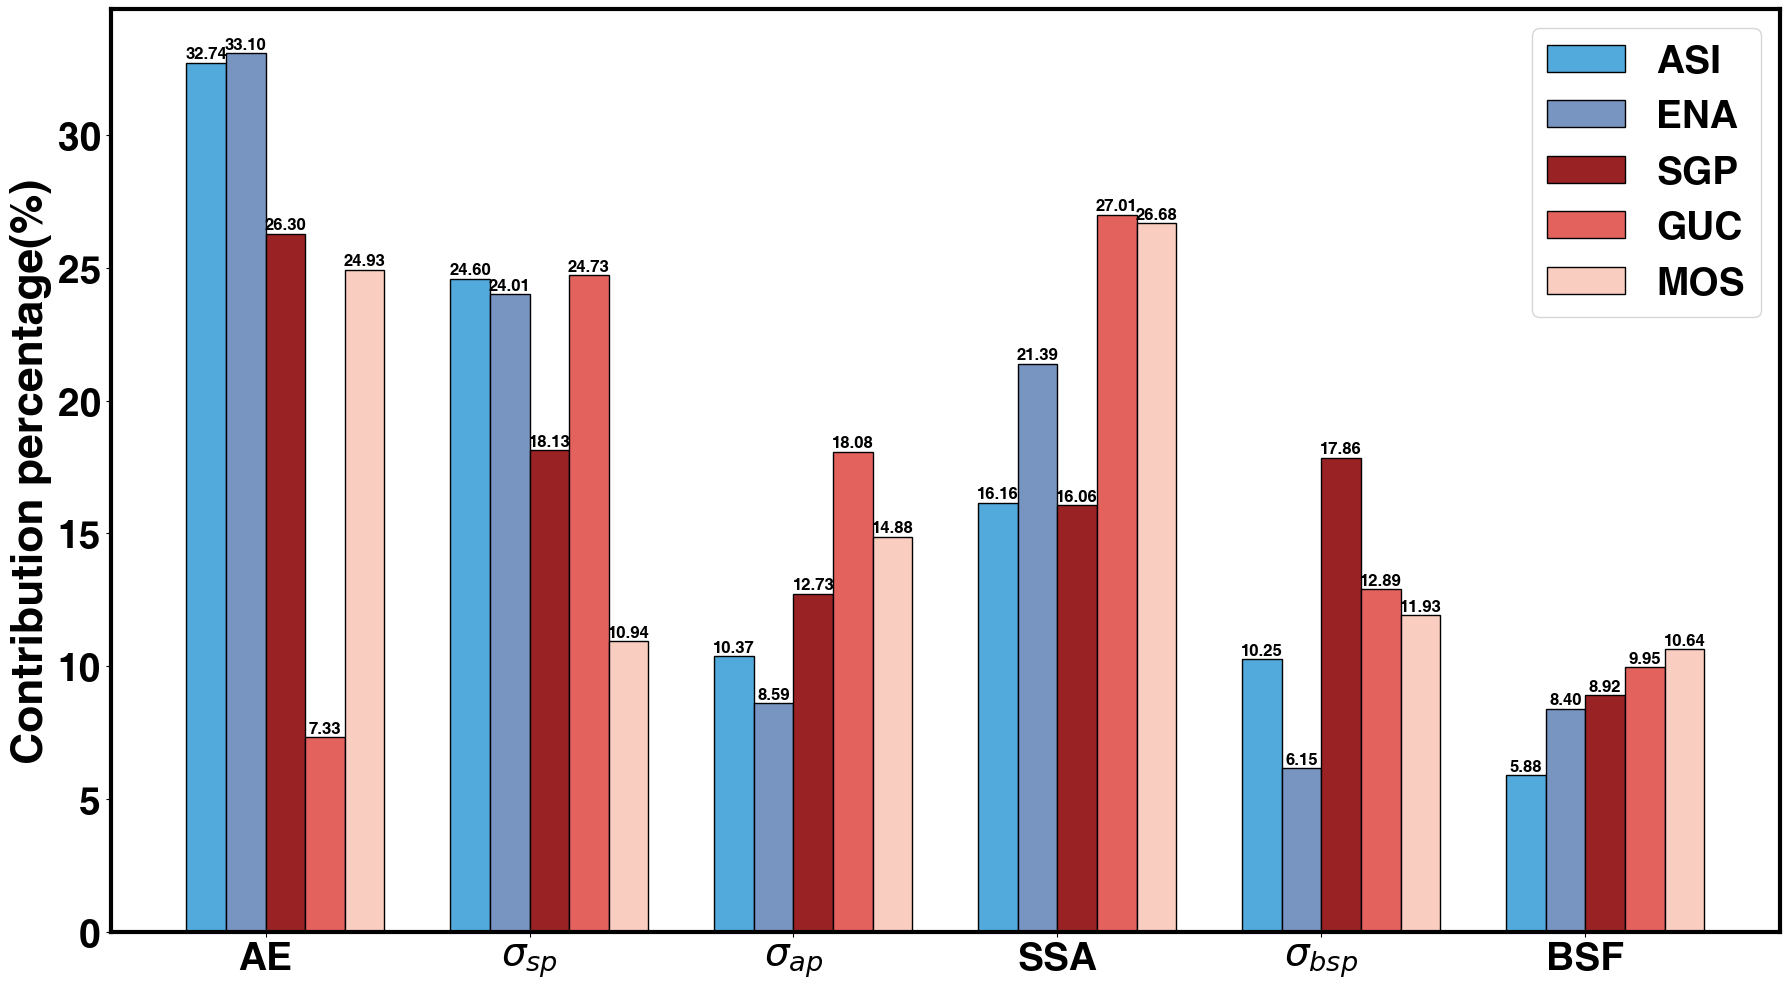

In [13]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'
plt.figure(figsize=(18, 10)) 

# values_grouped = [
#     (AE_ASI, BS_ASI, BA_ASI, SSA_ASI,  BBS_ASI,  BSF_ASI),
#     (AE_ENA, BS_ENA, BA_ENA, SSA_ENA,  BBS_ENA,  BSF_ENA),
#     (AE_SGP, BS_SGP, BA_SGP, SSA_SGP,  BBS_SGP,  BSF_SGP),
#     (AE_GUC, BS_GUC, BA_GUC, SSA_GUC,  BBS_GUC,  BSF_GUC),
#     (AE_mos, BS_mos, BA_mos, SSA_mos,  BBS_mos,  BSF_mos)
# ]
values_grouped = [
    (AE_ASIh, BS_ASIh, BA_ASIh, SSA_ASIh,  BBS_ASIh,  BSF_ASIh),
    (AE_ENAh, BS_ENAh, BA_ENAh, SSA_ENAh,  BBS_ENAh,  BSF_ENAh),
    (AE_SGPh, BS_SGPh, BA_SGPh, SSA_SGPh,  BBS_SGPh,  BSF_SGPh),
    (AE_GUCh, BS_GUCh, BA_GUCh, SSA_GUCh,  BBS_GUCh,  BSF_GUCh),
    (AE_mosh, BS_mosh, BA_mosh, SSA_mosh,  BBS_mosh,  BSF_mosh)
]

labels_grouped = ['ASI', 'ENA', 'SGP', 'GUC','MOS']

colors = ['#52AADC', '#7895C1', '#992224', '#E3625D','#F9CDBF']

bar_width = 0.15
bar_positions = np.arange(len(values_grouped[0]))

for i, (group, label, color) in enumerate(zip(values_grouped, labels_grouped, colors)):
    plt.bar(bar_positions + i * bar_width, group, width=bar_width, label=label, color=color, edgecolor='black')
    for j, value in enumerate(group):
        plt.text(bar_positions[j] + i * bar_width, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', fontname='Helvetica')

plt.xticks(bar_positions + bar_width * 1.5, ['AE', '$\sigma_{sp}$', '$\sigma_{ap}$', 'SSA',  '$\sigma_{bsp}$',  'BSF'], fontsize=28, fontweight='bold', fontname='Helvetica')
plt.ylabel('Contribution percentage(%)', fontsize=32, fontname='Helvetica', fontweight='bold')
plt.yticks(fontsize=28, fontname='Helvetica', fontweight='bold')
plt.legend(prop={'weight': 'bold', 'size': 28, 'family': 'Helvetica'}, loc='upper right')

ax = plt.gca()
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)

plt.tight_layout() 
# plt.savefig('E:/aabc/summary/fig-250416/contribution-ar.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


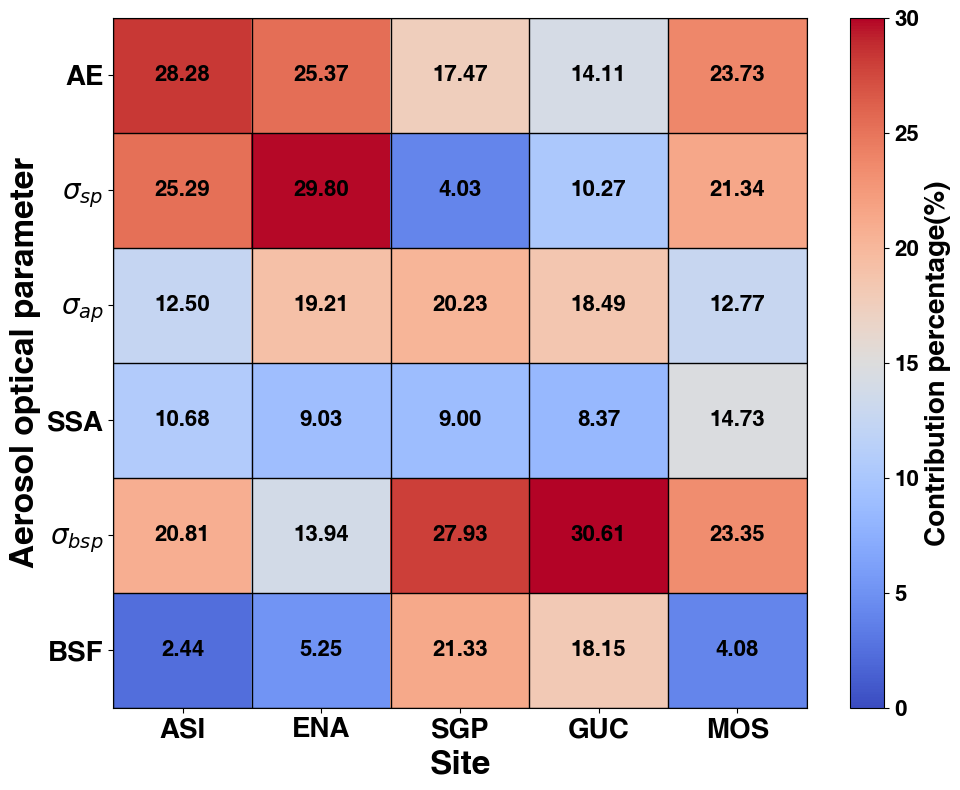

In [11]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'

data = np.array([
    [AE_ASI, AE_ENA, AE_SGP, AE_GUC, AE_mos],
    [BS_ASI, BS_ENA, BS_SGP, BS_GUC, BS_mos],
    [BA_ASI, BA_ENA, BA_SGP, BA_GUC, BA_mos],
    [SSA_ASI, SSA_ENA, SSA_SGP, SSA_GUC, SSA_mos],
    # [G_ASI, G_ENA, G_SGP, G_GUC],
    [BBS_ASI, BBS_ENA, BBS_SGP, BBS_GUC, BBS_mos],
    # [TRAN_ASI, TRAN_ENA, TRAN_SGP, TRAN_GUC],
    [BSF_ASI, BSF_ENA, BSF_SGP, BSF_GUC, BSF_mos]
])
labels_grouped = ['ASI', 'ENA', 'SGP', 'GUC','MOS']
values_grouped = [
    (AE_ASI, BS_ASI, BA_ASI, SSA_ASI,  BBS_ASI,  BSF_ASI),
    (AE_ENA, BS_ENA, BA_ENA, SSA_ENA,  BBS_ENA,  BSF_ENA),
    (AE_SGP, BS_SGP, BA_SGP, SSA_SGP,  BBS_SGP,  BSF_SGP),
    (AE_GUC, BS_GUC, BA_GUC, SSA_GUC,  BBS_GUC,  BSF_GUC),
    (AE_mos, BS_mos, BA_mos, SSA_mos,  BBS_mos,  BSF_mos)
]

fig, ax = plt.subplots(figsize=(10, 8))

# Set vmin and vmax for color range control
cax = ax.imshow(data, cmap='coolwarm', aspect='auto', vmin=0, vmax=30)

cbar = fig.colorbar(cax, ax=ax, orientation='vertical')
cbar.ax.set_ylabel('Contribution percentage(%)', fontsize=20, fontname='Helvetica', fontweight='bold')
cbar.ax.tick_params(labelsize=16) 

ax.set_xticks(np.arange(len(labels_grouped)))
ax.set_xticklabels(labels_grouped, fontsize=20)
ax.set_yticks(np.arange(len(values_grouped[0])))
ax.set_yticklabels(['AE', '$\sigma_{sp}$', '$\sigma_{ap}$', 'SSA', '$\sigma_{bsp}$', 'BSF'], fontsize=20)

ax.set_xlabel('Site', fontsize=24, fontname='Helvetica', fontweight='bold')
ax.set_ylabel('Aerosol optical parameter', fontsize=24, fontname='Helvetica', fontweight='bold')

ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True)
ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True)
ax.grid(which="minor", color="k", linestyle='-', linewidth=1)
ax.tick_params(which="minor", size=0)

# Add text labels to each cell
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', fontsize=16, fontname='Helvetica', color='black', fontweight='bold')

plt.tight_layout()
# plt.savefig('E:/aabc/summary/fig-250416/ccn_contribution_heatmap.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
